In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
!pip install tensorflow # Install tensorflow if not already installed
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

  Using cached tensorflow-2.20.0-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (4.5 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.9.23-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-manylinux2010_x86_64.whl.metadata (5.2 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached wheel-0.45.1-py3-none-any.whl.metadata (2.3 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-manylinux_2_31_x86_64.whl.metadata (1.1 kB)
  Using cached werkzeug-3.1.3-py3-none-any.whl.metadata (3.7 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.7/620.7 MB 823.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [5]:
VOCAB_SIZE = 10000       # top 10k words
MAX_LEN = 200            # pad / truncate reviews to this length
EMBED_DIM = 128
LSTM_UNITS = 128
BATCH_SIZE = 64
EPOCHS = 8               # choose between 6-10 as requested
RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


In [6]:
print("Loading IMDb dataset (top {} words)...".format(VOCAB_SIZE))
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)
print(f"Train samples: {len(x_train)}, Test samples: {len(x_test)}")


Loading IMDb dataset (top 10000 words)...
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train samples: 25000, Test samples: 25000


In [7]:
print(f"Padding sequences to length {MAX_LEN}...")
x_train_pad = pad_sequences(x_train, maxlen=MAX_LEN, padding='post', truncating='post')
x_test_pad  = pad_sequences(x_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print("x_train_pad shape:", x_train_pad.shape)


Padding sequences to length 200...
x_train_pad shape: (25000, 200)


In [8]:
model = models.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    layers.LSTM(LSTM_UNITS, return_sequences=False),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(1, activation='sigmoid')   # binary classification
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    x_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.15,   # keep a validation slice from training data
    verbose=2
)


Epoch 1/8
333/333 - 68s - 203ms/step - accuracy: 0.5250 - loss: 0.6948 - val_accuracy: 0.5648 - val_loss: 0.6871
Epoch 2/8
333/333 - 62s - 186ms/step - accuracy: 0.5798 - loss: 0.6788 - val_accuracy: 0.5597 - val_loss: 0.6821
Epoch 3/8
333/333 - 61s - 184ms/step - accuracy: 0.5705 - loss: 0.6704 - val_accuracy: 0.5432 - val_loss: 0.6691
Epoch 4/8
333/333 - 61s - 184ms/step - accuracy: 0.6636 - loss: 0.6162 - val_accuracy: 0.6869 - val_loss: 0.6161
Epoch 5/8
333/333 - 61s - 184ms/step - accuracy: 0.7258 - loss: 0.5506 - val_accuracy: 0.7915 - val_loss: 0.5059
Epoch 6/8
333/333 - 61s - 184ms/step - accuracy: 0.8126 - loss: 0.4459 - val_accuracy: 0.8141 - val_loss: 0.4580
Epoch 7/8
333/333 - 61s - 185ms/step - accuracy: 0.8845 - loss: 0.2991 - val_accuracy: 0.8309 - val_loss: 0.4101
Epoch 8/8
333/333 - 61s - 184ms/step - accuracy: 0.9198 - loss: 0.2241 - val_accuracy: 0.8349 - val_loss: 0.4376


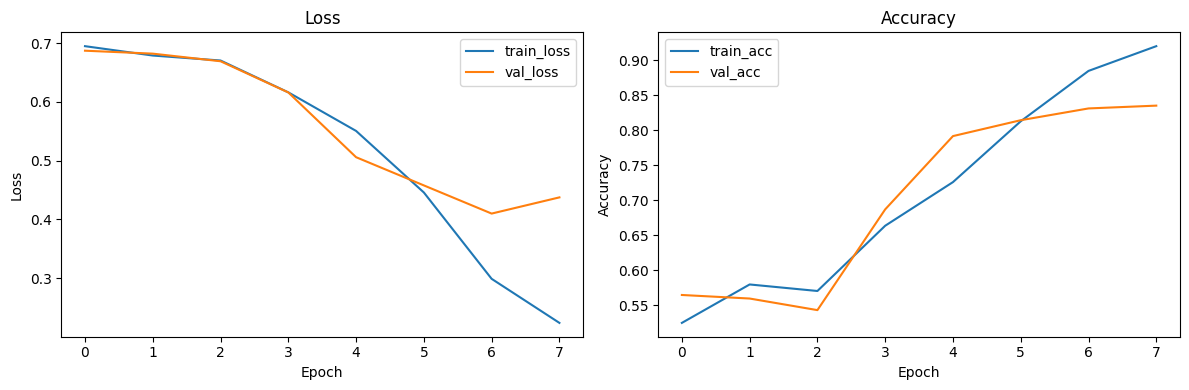

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss'); plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.title('Accuracy'); plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
test_loss, test_acc = model.evaluate(x_test_pad, y_test, verbose=0)
print(f"\nTest Loss: {test_loss:.4f}  |  Test Accuracy: {test_acc*100:.2f}%")



Test Loss: 0.4538  |  Test Accuracy: 82.80%


In [ ]:
y_pred_probs = model.predict(x_test_pad, batch_size=128, verbose=0).flatten()
y_pred = (y_pred_probs >= 0.5).astype(int)


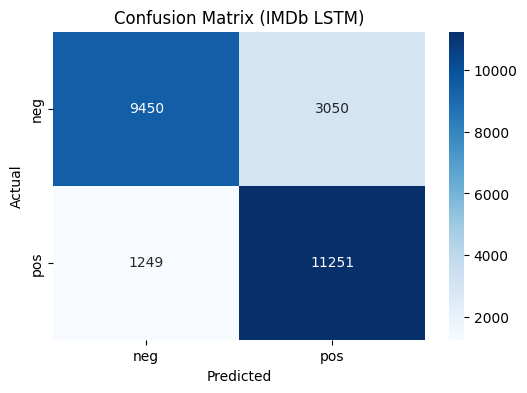

In [ ]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['neg','pos'], yticklabels=['neg','pos'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title('Confusion Matrix (IMDb LSTM)')
plt.show()


In [ ]:
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['negative','positive']))



Classification Report:
              precision    recall  f1-score   support

    negative       0.88      0.76      0.81     12500
    positive       0.79      0.90      0.84     12500

    accuracy                           0.83     25000
   macro avg       0.83      0.83      0.83     25000
weighted avg       0.83      0.83      0.83     25000

